# Analysis: notes

### steps
1. Data preparation
     1. pandas to load data + inspect/lint
     2. prepare columns
     3. prepare string encodings

Encodings = MLE, see encoded_test_data.csv

2. Model preparation
   1.  load all-mpnet-base-v2 model via sentence-transformers library

3. Embeddings
     1. encode() source and target questions
     2. source_embedding, target_embedding *columns*
     3. error handling ?!

4. Similarity
     1. cosine for source and target embeddings per pair
     2. similarity_score *column*

### notes

Start with a data set containing feature encodings, which are binary values that indicate whether an indexed example has certain features from our feature set. These were created via MultiLabelBinarize from url: . See main.py

The next step is to generate model embeddings. These are usually dense numerical vectors that represent the meaning of a text. In this project I used the url: for model + model card, either paraphrase-multilingual-MiniLM-L12-v2 or LaBSE

For our particular task, we want to generate two sets of embeddings, one for non-english question(source) and one of the english question (target)

In [15]:
# import the required libraries
from sentence_transformers import SentenceTransformer # loads the model and generates embeddings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm


In [ ]:
# 1. Load data from data/encoded_test_data.csv

data = pd.read_csv('data/encoded_test_data.csv')

# 2. Load model from sentence transformers
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\robin\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\robin\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [13]:
# generate embeddings for all examples in the data, one embedding per source question and one embedding per target question

print("Generating embeddings for source questions...")
source_embeddings = model.encode(data['source'].tolist(), show_progress_bar=True)

print('Generating embeddings for target questions...')
target_embeddings = model.encode(data['target'].tolist(), show_progress_bar=True)

# uncomment below print statements to see what the embeddings look like, ndim vector; only print one embedding at a time because of size issues

# print(f'source embedding:{source_embeddings[0]}')
# print(f'target embedding:{target_embeddings[0]}')

np.save('source_embeddings.npy', source_embeddings)
np.save('target_embeddings.npy', target_embeddings)




Generating embeddings for source questions...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Generating embeddings for target questions...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [14]:
# calculate cosine similarity of all examples
similarities = []
for s_emb, t_emb in zip(source_embeddings, target_embeddings):
  sim = np.dot(s_emb, t_emb) / (np.linalg.norm(s_emb) * np.linalg.norm(t_emb))
  similarities.append(sim)


# augment the original data with the sim scores

data['cosine_similarity'] = similarities

data.to_csv('questions_similarities.csv')


def load_data():
  sim_data = pd.read_csv('questions_similarities.csv')
  source_embeddings = np.load('source_embeddings.npy')
  target_embeddings = np.load('target_embeddings.npy')
  return sim_data, source_embeddings, target_embeddings



print('Results of similarity analysis:')
print(data['cosine_similarity'].describe())


Results of similarity analysis:
count    500.000000
mean       0.153343
std        0.142856
min       -0.132780
25%        0.052763
50%        0.116060
75%        0.214105
max        0.744082
Name: cosine_similarity, dtype: float64


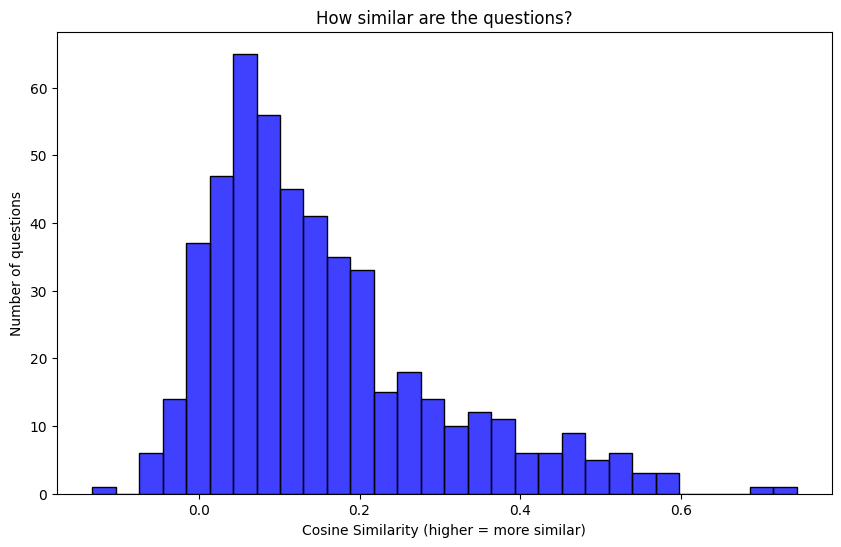

In [12]:
#visualizations

#similarity analysis
plt.figure(figsize=(10, 6))  # make the plot bigger
sns.histplot(data=data, x='cosine_similarity', bins=30, color='blue')  # i like blue
plt.title('How similar are the questions?')
plt.xlabel('Cosine Similarity (higher = more similar)')
plt.ylabel('Number of questions')
plt.show()

In [17]:
# debugging
data = pd.read_csv('data/encoded_test_data.csv')

test_samples = data.head(3)

for _, row in test_samples.iterrows():
  print(f"\nSource ({row['language']}): {row['source']}")
  print(f"Target (en): {row['target']}")


print("\nLoading model...")
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
print(f"Model max sequence length: {model.max_seq_length}")
print(f"Model embedding dimension: {model.get_sentence_embedding_dimension()}")

# Generate embeddings for test samples
print("\nGenerating test embeddings...")
source_test_embs = model.encode(test_samples['source'].tolist())
target_test_embs = model.encode(test_samples['target'].tolist())

# Check embedding properties
print("\nEmbedding checks:")
print(f"Shape of source embeddings: {source_test_embs.shape}")
print(f"Shape of target embeddings: {target_test_embs.shape}")
print(f"Range of values in first source embedding: [{source_test_embs[0].min():.3f}, {source_test_embs[0].max():.3f}]")

# Calculate similarities for test samples
print("\nTest similarities:")
for i in range(len(test_samples)):
    # Normalize vectors (just to be extra sure)
    src_norm = source_test_embs[i] / np.linalg.norm(source_test_embs[i])
    tgt_norm = target_test_embs[i] / np.linalg.norm(target_test_embs[i])
    
    # Calculate similarity
    sim = np.dot(src_norm, tgt_norm)
    print(f"Pair {i+1} similarity: {sim:.3f}")
    
# Let's also try a sanity check with English-English pairs
print("\nSanity check with English pairs:")
eng_pairs = [
    ("What is your name?", "What's your name?"),  # Should be very similar
    ("What is your name?", "How old are you?"),   # Should be different
]

eng_embs1 = model.encode([p[0] for p in eng_pairs])
eng_embs2 = model.encode([p[1] for p in eng_pairs])

for i, (q1, q2) in enumerate(eng_pairs):
    sim = np.dot(eng_embs1[i], eng_embs2[i]) / (np.linalg.norm(eng_embs1[i]) * np.linalg.norm(eng_embs2[i]))
    print(f"\nPair: '{q1}' vs '{q2}'")
    print(f"Similarity: {sim:.3f}")

# If everything looks good, generate embeddings for full dataset
if input("\nProceed with full dataset? (y/n): ").lower() == 'y':
    print("\nGenerating embeddings for full dataset...")
    source_embs = model.encode(data['source'].tolist(), show_progress_bar=True)
    target_embs = model.encode(data['target'].tolist(), show_progress_bar=True)
    
    # Save embeddings
    np.save('source_embeddings.npy', source_embs)
    np.save('target_embeddings.npy', target_embs)
    
    # Calculate and save similarities
    similarities = []
    for s_emb, t_emb in tqdm(zip(source_embs, target_embs), total=len(source_embs)):
        sim = np.dot(s_emb, t_emb) / (np.linalg.norm(s_emb) * np.linalg.norm(t_emb))
        similarities.append(sim)
    
    data['cosine_similarity'] = similarities
    data.to_csv('questions_with_similarities.csv')
    
    # Print final statistics
    print("\nFinal similarity statistics:")
    print(pd.Series(similarities).describe())



Source (af): Waarom God alle ellende toelaat?
Target (en): Why does God allow all the evil in the world?

Source (id): Adakah Boris Johnson akan berjaya mencapai perjanjian dagang yang adil dengan EU, dan jika benar, seberapa pantas?
Target (en): Will Boris Johnson manage to reach a free trade agreement with the EU and, if so, how fast?

Source (af): (Prediker 1:9) Vraag: Does dit impliseer dat daarse allerhande nuwe dinge oor Die son, wat is geleë in ons klein sonnestelsel?
Target (en): (Ecclesiastes 1:9) Question: Does this imply that there's all manner of new things over the sun, which is situated in our tiny solar system?

Loading model...
Model max sequence length: 384
Model embedding dimension: 768

Generating test embeddings...

Embedding checks:
Shape of source embeddings: (3, 768)
Shape of target embeddings: (3, 768)
Range of values in first source embedding: [-0.154, 0.125]

Test similarities:
Pair 1 similarity: 0.189
Pair 2 similarity: 0.418
Pair 3 similarity: 0.238

Sanity

In [18]:
test_pairs = [
    # Same meaning, different languages
    ("Why do you like it?", "Waarom hou jy daarvan?", "en-af"),  # English-Afrikaans
    ("How are you?", "Apa kabar?", "en-id"),                     # English-Indonesian
    ("What is this?", "ما هذا؟", "en-ar"),                       # English-Arabic
    ("Where are you going?", "तू कुठे चाललास?", "en-mr"),        # English-Marathi
    
    # Control: English-English with varying similarity
    ("Why do you like it?", "What makes you enjoy it?", "en-en-similar"),
    ("Why do you like it?", "Where is the store?", "en-en-different")
]

# Test each pair
print("Testing pairs:")
for q1, q2, lang_pair in test_pairs:
    # Get embeddings
    emb1 = model.encode(q1)
    emb2 = model.encode(q2)
    
    # Calculate similarity
    sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    
    print(f"\nLanguage pair: {lang_pair}")
    print(f"Q1: {q1}")
    print(f"Q2: {q2}")
    print(f"Similarity: {sim:.3f}")

# Also test normalization effects
print("\nChecking normalization effects...")
for q1, q2, lang_pair in test_pairs[:1]:  # Just use first pair
    emb1 = model.encode(q1)
    emb2 = model.encode(q2)
    
    # Different normalization approaches
    # 1. Original
    sim1 = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
    
    # 2. Normalize before dot product
    emb1_norm = emb1 / np.linalg.norm(emb1)
    emb2_norm = emb2 / np.linalg.norm(emb2)
    sim2 = np.dot(emb1_norm, emb2_norm)
    
    print(f"\nNormalization comparison:")
    print(f"Original method: {sim1:.3f}")
    print(f"Pre-normalized: {sim2:.3f}")

Testing pairs:

Language pair: en-af
Q1: Why do you like it?
Q2: Waarom hou jy daarvan?
Similarity: 0.160

Language pair: en-id
Q1: How are you?
Q2: Apa kabar?
Similarity: 0.073

Language pair: en-ar
Q1: What is this?
Q2: ما هذا؟
Similarity: 0.137

Language pair: en-mr
Q1: Where are you going?
Q2: तू कुठे चाललास?
Similarity: 0.039

Language pair: en-en-similar
Q1: Why do you like it?
Q2: What makes you enjoy it?
Similarity: 0.552

Language pair: en-en-different
Q1: Why do you like it?
Q2: Where is the store?
Similarity: 0.174

Checking normalization effects...

Normalization comparison:
Original method: 0.160
Pre-normalized: 0.160
